<a href="https://colab.research.google.com/github/andressonsino/student-ai-impact-analysis/blob/main/notebooks/impact_of_ia_on_students_spa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

In [5]:
# ── Configuración ──────────────────────────────────────────
DATA_PATH_LOCAL= r"../data/raw/ai_student_impact_dataset_raw.csv"
DRIVE_PATH_REL = "MyDrive/trabajo/ds/datasets/ifts/ai_student_impact_dataset.csv"
SEPARATOR = ","
ENCODING  = "utf-8"

df_raw = None

# ── Prioridad 1: archivo local ─────────────────────────────
import os
if os.path.exists(DATA_PATH_LOCAL):
    df_raw = pd.read_csv(DATA_PATH_LOCAL, sep=SEPARATOR, encoding=ENCODING)
    print(f"✅ Dataset cargado desde archivo local: {DATA_PATH_LOCAL}")

# ── Prioridad 2: Google Drive (solo si estamos en Colab) ──
if df_raw is None:
    try:
        # Detectamos si estamos en Colab
        import sys
        IN_COLAB = 'google.colab' in sys.modules
    except:
        IN_COLAB = False

    if IN_COLAB:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            ruta_drive = f"/content/drive/{DRIVE_PATH_REL}"
            df_raw = pd.read_csv(ruta_drive, sep=SEPARATOR, encoding=ENCODING)
            print(f"✅ Dataset cargado desde Google Drive: {ruta_drive}")
        except Exception as e:
            print(f"⚠️ Error al cargar desde Google Drive: {e}")
    else:
        print("ℹ️ No estás en Colab. Omitiendo carga desde Google Drive.")

# ── Prioridad 3: error si no se pudo cargar ────────────────
if df_raw is None:
    raise FileNotFoundError(
        f"No se pudo cargar el dataset.\n"
        f"Opciones:\n"
        f"  1. Colocá el archivo en: {DATA_PATH_LOCAL}\n"
        f"  2. Si usás Colab, ajustá DRIVE_PATH_REL y asegurate de tener el archivo en Drive.\n"
        f"  3. Subí el archivo manualmente a Colab con files.upload() y ajustá la ruta."
    )

print(f"\nDataset listo — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset cargado desde Google Drive: /content/drive/MyDrive/trabajo/ds/datasets/ifts/ai_student_impact_dataset.csv

Dataset listo — Filas: 50000 | Columnas: 16


# LIMPIEZA

In [6]:
# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
# Verificamos si hay algún nulo en toda la tabla
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    # Sino mostramos tabla filtrada de nulos
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.42,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.39,86.44,High
1,100002,Medical,Junior,3.82,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.70,69.39,Low
2,100003,Business,Freshman,3.40,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.50,73.93,Medium
3,100004,Business,Senior,3.79,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.00,63.58,Medium
4,100005,STEM,Sophomore,3.63,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.80,100.00,Medium



--- Últimas 5 filas ---


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.90,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.58,66.16,High
49996,149997,STEM,Senior,2.87,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.10,81.62,Medium
49997,149998,Business,Senior,3.18,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.60,97.21,High
49998,149999,Business,Junior,3.40,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.53,84.12,Medium
49999,150000,Arts,Sophomore,3.24,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.26,76.16,Low


Filas: 50000 | Columnas: 16

--- Info general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,125000.50,3.15,8.43,2.80,11.21,3.51,4.27,3.35,75.80
std,14433.90,0.48,8.27,1.19,5.16,1.82,2.14,0.50,13.28
min,100001.00,1.18,0.00,1.00,1.00,1.00,1.00,1.00,10.78
25%,112500.75,2.83,2.39,2.00,7.56,2.00,3.00,3.02,66.82
50%,125000.50,3.21,5.80,3.00,11.18,3.00,4.00,3.42,76.00
75%,137500.25,3.52,11.72,4.00,14.71,5.00,6.00,3.75,85.19
max,150000.00,4.00,40.00,5.00,35.86,10.00,10.00,4.00,100.00


## TRADUCCIÓN DE CONTENIDO AL ESPAÑOL
Realizo traducción del contenido del dataset mediante diccionarios para poder trabajar en español.

In [7]:
# 1. Diccionario para renombrar encabezados de columnas
diccionario_columnas = {
    'Student_ID': 'ID del estudiante',
    'Major_Category': 'Categoría de carrera',
    'Year_of_Study': 'Año de cursada',
    'Pre_Semester_GPA': 'Promedio académico antes del semestre',
    'Weekly_GenAI_Hours': 'Horas semanales de uso de IA generativa',
    'Primary_Use_Case': 'Uso principal de la IA',
    'Prompt_Engineering_Skill': 'Nivel de habilidad en ingeniería de prompts',
    'Tool_Diversity': 'Diversidad de herramientas de IA utilizadas',
    'Paid_Subscription': 'Tiene suscripción paga',
    'Traditional_Study_Hours': 'Horas de estudio tradicional',
    'Perceived_AI_Dependency': 'Dependencia percibida de la IA',
    'Institutional_Policy': 'Política institucional sobre uso de IA',
    'Anxiety_Level_During_Exams': 'Nivel de ansiedad durante exámenes',
    'Post_Semester_GPA': 'Promedio académico después del semestre',
    'Skill_Retention_Score': 'Puntaje de retención de habilidades',
    'Burnout_Risk_Level': 'Nivel de riesgo de agotamiento mental'
}

# 2. Diccionario para traducir el contenido de las celdas (filas)
diccionario_contenido = {
    'Categoría de carrera': {
        'Humanities': 'Humanidades',
        'Medical': 'Medicina',
        'Business': 'Negocios',
        'STEM': 'CTIM (Ciencias, Tecnología, Ing. y Matemáticas)',
        'Arts': 'Artes'
    },
    "Año de cursada" : {
    'Freshman': '1er año',
    'Sophomore': '2do año',
    'Junior': '3er año',
    'Senior': '4to año'
    },
    'Uso principal de la IA': {
        'Copywriting/Drafting': 'Redacción/Borradores',
        'Ideation': 'Ideación',
        'Summarizing_Reading': 'Resumir_Lectura',
        'Debugging/Troubleshooting': 'Depuración/Resolución_de_Problemas'
    },
    'Nivel de habilidad en ingeniería de prompts': {
        'Beginner': 'Principiante',
        'Intermediate': 'Intermedio',
        'Advanced': 'Avanzado'
    },
    'Política institucional sobre uso de IA': {
        'Allowed_With_Citation': 'Permitido con cita',
        'Strict_Ban': 'Prohibición estricta',
        'Actively_Encouraged': 'Fomentado activamente'
    },
    'Nivel de riesgo de agotamiento mental': {
        'Low': 'Bajo',
        'Medium': 'Medio',
        'High': 'Alto'
    }
}

# --- EJECUCIÓN DEL CAMBIO ---

# Paso A: Renombrar títulos de columnas
df_raw = df_raw.rename(columns=diccionario_columnas)

# Paso B: Traducir el contenido de las filas
df_raw = df_raw.replace(diccionario_contenido)

# Paso C: Traducir la columna True/False
df_raw['Tiene suscripción paga'] = df_raw['Tiene suscripción paga'].replace({
    True: 'Sí', False: 'No', 'True': 'Sí', 'False': 'No'
})

print("✅ Columnas y filas traducidas correctamente")

✅ Columnas y filas traducidas correctamente


In [8]:
# Detectar con IQR
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    print(f'{columna}:')
    print(f'  Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n')
    return lim_inf, lim_sup

# Bucle for para utilizar esta funcion en cada columna
# Filtramos para agarrar solo las columnas que tienen números (ignoramos textos/nombres)
columnas_numericas = df_raw.select_dtypes(include=['number']).columns

# Hacemos que Python pase la función por cada una de esas columnas automáticamente
for col in columnas_numericas:
    detectar_outliers(df_raw, col)
    print("-" * 40) # Imprime una línea separadora para que se lea mejor

ID del estudiante:
  Rango normal: [75001.50, 174999.50]
  Outliers: 0 (0.0%)

----------------------------------------
Promedio académico antes del semestre:
  Rango normal: [1.80, 4.55]
  Outliers: 328 (0.7%)

----------------------------------------
Horas semanales de uso de IA generativa:
  Rango normal: [-11.61, 25.72]
  Outliers: 2583 (5.2%)

----------------------------------------
Diversidad de herramientas de IA utilizadas:
  Rango normal: [-1.00, 7.00]
  Outliers: 0 (0.0%)

----------------------------------------
Horas de estudio tradicional:
  Rango normal: [-3.17, 25.44]
  Outliers: 161 (0.3%)

----------------------------------------
Dependencia percibida de la IA:
  Rango normal: [-2.50, 9.50]
  Outliers: 190 (0.4%)

----------------------------------------
Nivel de ansiedad durante exámenes:
  Rango normal: [-1.50, 10.50]
  Outliers: 0 (0.0%)

----------------------------------------
Promedio académico después del semestre:
  Rango normal: [1.94, 4.84]
  Outliers: 346 (

## ¿Cómo funciona el método IQR?

El código utiliza el **Método del Rango Intercuartílico (IQR)** (o Cercas de Tukey),
una técnica estadística que analiza el 50% central de los datos para calcular fronteras de tolerancia.

**Paso 1 — Identificar los cuartiles (Q1 y Q3)**  
- Q1 (Percentil 25): el valor donde se acumula el 25% de los datos más bajos.  
- Q3 (Percentil 75): el valor donde se acumula el 75% de los datos.

**Paso 2 — Medir el rango central (IQR)**  
`IQR = Q3 - Q1`: es la distancia que contiene la mitad central de la muestra.

**Paso 3 — Construir los límites de tolerancia**  
- `lim_inf = Q1 - 1.5 × IQR`  
- `lim_sup = Q3 + 1.5 × IQR`  

> ¿Por qué 1.5? Es la constante estándar definida por Tukey para filtrar valores
> verdaderamente atípicos sin descartar variaciones normales.

**Paso 4 — Evaluar qué datos quedan fuera**  
Cualquier fila por debajo de `lim_inf` o por encima de `lim_sup` es clasificada como outlier.

**Ejemplo numérico:** si en Horas de estudio Q1 = 10 y Q3 = 20:  
IQR = 10 → lim_inf = -5 → lim_sup = 35.  
Todo estudiante con más de 35 horas sería outlier.

In [9]:
# 1. Definimos la columna que queremos investigar
columna = 'Horas semanales de uso de IA generativa'

# 2. Volvemos a calcular el límite superior estadístico (IQR)
Q1 = df_raw[columna].quantile(0.25)
Q3 = df_raw[columna].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR

# 3. AISLAMIENTO: Creamos un subgrupo (DataFrame) solo con los alumnos que superan el límite
df_outliers_ia = df_raw[df_raw[columna] > lim_sup]

# 4. ANÁLISIS EN BLOQUE: Le pedimos estadísticas descriptivas SOLO a este subgrupo
print(f"--- Análisis del subgrupo de {len(df_outliers_ia)} Outliers ---")
display(df_outliers_ia.describe())

--- Análisis del subgrupo de 2583 Outliers ---


,ID del estudiante,Promedio académico antes del semestre,Horas semanales de uso de IA generativa,Diversidad de herramientas de IA utilizadas,Horas de estudio tradicional,Dependencia percibida de la IA,Nivel de ansiedad durante exámenes,Promedio académico después del semestre,Puntaje de retención de habilidades
count,2583.00,2583.00,2583.00,2583.00,2583.00,2583.00,2583.00,2583.00,2583.00
mean,125075.03,3.14,32.73,2.82,8.83,7.14,5.87,3.28,66.18
std,14494.92,0.49,4.83,1.18,4.93,1.57,2.38,0.54,15.20
min,100007.00,1.43,25.72,1.00,1.00,3.00,1.00,1.00,10.78
25%,112416.00,2.81,28.35,2.00,5.02,6.00,4.00,2.92,56.03
50%,125201.00,3.21,32.10,3.00,8.57,7.00,6.00,3.36,66.57
75%,137429.50,3.52,37.16,4.00,12.30,8.00,8.00,3.72,76.58
max,149987.00,3.99,40.00,5.00,28.80,10.00,10.00,4.00,100.00


- En los outliers de la columna el min arranca en 25.72 y el max frena exactamente en 40.00.


- Si comparamos los promedios de este grupo de usuarios intensivos contra los promedios generales que vimos en el dataset original, todo tiene una lógica:

**Conclusiones**

No hay errores de tipeo absurdos (como 999 horas). 40 horas a la semana son menos de 6 horas al día. Es un uso extremo, pero humanamente posible.

Dependencia de la IA: El promedio general de todos tus alumnos era de 3.51. Pero en este grupo extremo saltó a 7.14.
Es lógico: los que la usan más de 25 horas son altamente dependientes.

Horas de estudio tradicional: El promedio general era de 11.21 horas. En este grupo cayó a 8.83. Tiene sentido: reemplazan el estudio clásico con el uso de herramientas generativas.

**Decisión sobre outliers:**

Se decide mantener los outliers detectados, ya que no son errores de carga, sino perfiles reales de estudiantes con uso intensivo de tecnología o situaciones académicas extremas. Estos casos son vitales para que el modelo aprenda a predecir correctamente el riesgo de burnout

In [10]:
# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()


--- Info general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ID del estudiante                            50000 non-null  int64  
 1   Categoría de carrera                         50000 non-null  object 
 2   Año de cursada                               50000 non-null  object 
 3   Promedio académico antes del semestre        50000 non-null  float64
 4   Horas semanales de uso de IA generativa      50000 non-null  float64
 5   Uso principal de la IA                       50000 non-null  object 
 6   Nivel de habilidad en ingeniería de prompts  50000 non-null  object 
 7   Diversidad de herramientas de IA utilizadas  50000 non-null  int64  
 8   Tiene suscripción paga                       50000 non-null  object 
 9   Horas de estudio tradicional                 50000

- Transformo la columna ID del estuiante en el índice de cada fila

In [11]:
# Convertimos la columna ID en el "nombre" de cada fila (Índice)
df_raw.set_index('ID del estudiante', inplace=True)

In [12]:
df_raw

,Categoría de carrera,Año de cursada,Promedio académico antes del semestre,Horas semanales de uso de IA generativa,Uso principal de la IA,Nivel de habilidad en ingeniería de prompts,Diversidad de herramientas de IA utilizadas,Tiene suscripción paga,Horas de estudio tradicional,Dependencia percibida de la IA,Política institucional sobre uso de IA,Nivel de ansiedad durante exámenes,Promedio académico después del semestre,Puntaje de retención de habilidades,Nivel de riesgo de agotamiento mental
ID del estudiante,,,,,,,,,,,,,,,
100001,Humanidades,4to año,2.42,23.31,Redacción/Borradores,Principiante,1,Sí,8.13,5,Permitido con cita,6,2.39,86.44,Alto
100002,Medicina,3er año,3.82,1.12,Ideación,Avanzado,5,No,16.65,3,Permitido con cita,9,3.70,69.39,Bajo
100003,Negocios,1er año,3.40,21.26,Resumir_Lectura,Principiante,2,No,10.35,5,Prohibición estricta,9,3.50,73.93,Medio
100004,Negocios,4to año,3.79,1.82,Redacción/Borradores,Intermedio,4,No,15.23,2,Permitido con cita,2,4.00,63.58,Medio
100005,"CTIM (Ciencias, Tecnología, Ing. y Matemáticas)",2do año,3.63,9.29,Depuración/Resolución_de_Problemas,Avanzado,4,No,12.55,4,Permitido con cita,4,3.80,100.00,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149996,Negocios,4to año,2.90,12.16,Redacción/Borradores,Principiante,2,No,13.36,2,Permitido con cita,2,3.58,66.16,Alto
149997,"CTIM (Ciencias, Tecnología, Ing. y Matemáticas)",4to año,2.87,2.51,Redacción/Borradores,Intermedio,1,No,4.67,3,Fomentado activamente,3,3.10,81.62,Medio
149998,Negocios,4to año,3.18,15.87,Resumir_Lectura,Avanzado,5,Sí,3.92,4,Permitido con cita,5,3.60,97.21,Alto


In [13]:
print('=' * 50)
print('REPORTE FINAL DE CALIDAD')
print('=' * 50)
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 50)

REPORTE FINAL DE CALIDAD
Filas finales:      50000
Columnas:           15
Duplicados:         0
Nulos totales:      0


In [14]:
# Renombrar a df_clean antes de exportar
df_clean = df_raw.copy()

# Exportar
nombre_salida = '../data/clean/ai_student_impact_dataset_clean.csv'
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'Dataset exportado: {nombre_salida}')
print(f'Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

OSError: Cannot save file into a non-existent directory: '../data/clean'

### Feature Engineering: Creación de Variables Financieras y de Rendimiento

Para profundizar el análisis y evaluar el impacto real de las herramientas generativas, transformaremos variables técnicas y categóricas en métricas de negocio. El objetivo principal es poder medir el **Retorno de Inversión (ROI) Académico**: ¿el gasto económico en IA se traduce en mejores calificaciones?

Para ello, construimos dos nuevas variables:

**1. Variación del GPA (Rendimiento Académico)**
Se calcula restando el promedio académico previo al semestre del promedio final. Esto nos otorga una métrica neta de crecimiento (valores positivos) o retroceso (valores negativos).

**2. Gasto Mensual Estimado en USD (Estimación Financiera)**
Dado que el dataset no provee el gasto exacto, aplicamos una regla de negocio basada en el costo promedio del mercado actual para herramientas de IA Generativa. El algoritmo de estimación sigue esta lógica:
* **Filtro Gratuito:** Si el estudiante indica que no posee una suscripción paga (`Tiene suscripción paga == 'No'`), el gasto estimado es de **$0**.
* **Tarifa Premium Base:** Si el estudiante paga por servicios, asumimos una suscripción principal (ej. ChatGPT Plus o Claude Pro) con un valor de mercado de **$20 USD mensuales**. Esta tarifa cubre la primera herramienta utilizada.
* **Herramientas Adicionales:** Por cada herramienta extra reportada en la columna `Diversidad de herramientas de IA utilizadas`, se suma un costo marginal de **$10 USD** (ej. integraciones como GitHub Copilot o Midjourney).

> **Ejemplo de cálculo:** Un estudiante con suscripción paga y una diversidad de 3 herramientas abonará: $20 (herramienta principal) + $20 (por las 2 herramientas adicionales) = **$40 USD mensuales.**

In [17]:
# Definimos la regla de negocio para estimar el costo
def estimar_gasto(fila):
    # Si no tiene suscripción paga, el gasto es $0
    if fila['Tiene suscripción paga'] == 'No':
        return 0
    else:
        # Si paga, calculamos $20 de base + $10 por cada herramienta adicional
        diversidad = fila['Diversidad de herramientas de IA utilizadas']
        costo_base = 20
        # (diversidad - 1) porque la primera herramienta ya está cubierta por el costo_base
        costo_extra = (diversidad - 1) * 10
        return costo_base + costo_extra

# Creamos la nueva columna financiera usando .apply()
df_clean['Gasto Mensual Estimado en USD'] = df_clean.apply(estimar_gasto, axis=1)

# Creamos la columna del ROI Académico (Diferencia de notas)
df_clean['Variacion GPA'] = df_clean['Promedio académico después del semestre'] - df_clean['Promedio académico antes del semestre']

# Mostramos una muestra para comprobar que funcionó
display(df_clean[['Tiene suscripción paga', 'Diversidad de herramientas de IA utilizadas', 'Gasto Mensual Estimado en USD', 'Variacion GPA']].sample(5))

,Tiene suscripción paga,Diversidad de herramientas de IA utilizadas,Gasto Mensual Estimado en USD,Variacion GPA
ID del estudiante,,,,
145706,Sí,3,40,0.24
127252,Sí,3,40,0.23
128784,Sí,3,40,0.19
131529,No,3,0,0.34
114576,Sí,3,40,0.02


## 📊 Análisis Exploratorio de Datos (EDA)

### Preguntas que guían el análisis

1. **¿Cómo se distribuye el uso de IA entre carreras y años de cursada?**
2. **¿El uso intensivo de IA se correlaciona con mejor o peor rendimiento académico (GPA)?**
3. **¿Los estudiantes con más horas de IA tienen mayor riesgo de burnout?**
4. **¿Qué política institucional predomina y cómo afecta el uso de la IA?**
5. **¿Los usuarios con suscripción paga usan más herramientas y tienen mejor habilidad en prompts?**

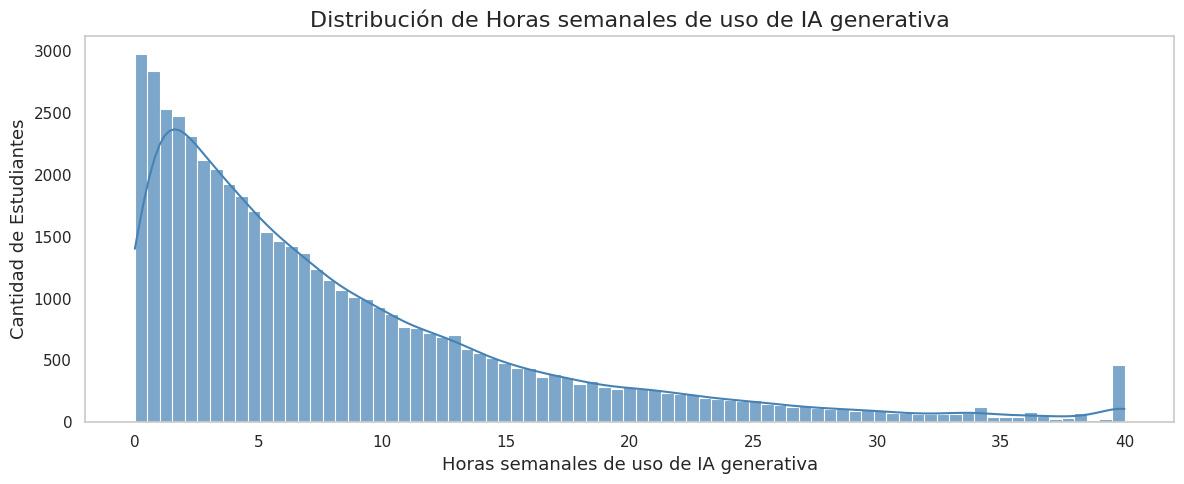

In [18]:
# columnas_numericas = df_raw.select_dtypes(include='number').columns.tolist()
columnas_especificas = ['Horas semanales de uso de IA generativa']
for col in columnas_especificas:
    plt.figure(figsize=(12, 5))
    sns.histplot(data=df_raw, x=col, kde=True, color='steelblue', alpha=0.7)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.grid(False)
    plt.ylabel('Cantidad de Estudiantes')
    plt.show()

### Conclusiones del Análisis Univariado (Perfil General)

Al analizar las distribuciones individuales de nuestras variables principales, podemos extraer dos grandes conclusiones sobre la muestra poblacional de los 50.000 estudiantes:

**1. El comportamiento de uso de IA es asimétrico (Right-skewed)**
El histograma de las horas semanales de uso de IA revela que la inmensa mayoría del alumnado hace un uso casual de la tecnología (concentrándose en el rango de 1 a 5 horas). Sin embargo, la curva presenta una "cola larga" hacia la derecha que culmina en un pico visible en la marca de las 40 horas. Visualmente, esto confirma nuestra hipótesis de limpieza: estos valores extremos no son errores de sistema, sino un nicho real de "heavy users" (usuarios intensivos) que resultarán clave para medir el riesgo de burnout.

**2. La muestra poblacional está perfectamente balanceada**
Al observar el gráfico de barras del año de cursada, notamos una distribución equitativa (uniforme) entre todos los niveles académicos, desde ingresantes (1er año) hasta posgrados (Graduate). Esto nos garantiza que los modelos predictivos y los cruces de variables que hagamos más adelante no tendrán sesgos de antigüedad (es decir, los resultados no estarán inclinados artificialmente porque había "demasiados alumnos de primer año").

*Nota:* Se observa un "efecto techo" (pico inusual) en la marca de las 40 horas. Esto sugiere que el método de recolección de datos agrupó a todos los usuarios extremos (40 horas o más) en un único valor máximo.

In [29]:
# ── Configuración ──────────────────────────────────────────
DATA_PATH_LOCAL_DS_EXT= r"../data/raw/"
DRIVE_PATH_REL_DS_EXT= "MyDrive/trabajo/ds/datasets/ifts/recent-grads.csv"
SEPARATOR = ","
ENCODING  = "utf-8"

df_ext = None

# ── Prioridad 1: archivo local ─────────────────────────────
if os.path.exists(DATA_PATH_LOCAL_DS_EXT):
    df_raw = pd.read_csv(DATA_PATH_LOCAL_DS_EXT, sep=SEPARATOR, encoding=ENCODING)
    print(f"✅ Dataset cargado desde archivo local: {DATA_PATH_LOCAL_DS_EXT}")

# ── Prioridad 2: Google Drive (solo si estamos en Colab) ──
if df_ext is None:
    try:
        # Detectamos si estamos en Colab
        import sys
        IN_COLAB = 'google.colab' in sys.modules
    except:
        IN_COLAB = False

    if IN_COLAB:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            ruta_drive = f"/content/drive/{DRIVE_PATH_REL_DS_EXT}"
            df_raw = pd.read_csv(ruta_drive, sep=SEPARATOR, encoding=ENCODING)
            print(f"✅ Dataset cargado desde Google Drive: {ruta_drive}")
        except Exception as e:
            print(f"⚠️ Error al cargar desde Google Drive: {e}")
    else:
        print("ℹ️ No estás en Colab. Omitiendo carga desde Google Drive.")

# ── Prioridad 3: error si no se pudo cargar ────────────────
if df_ext is None:
    raise FileNotFoundError(
        f"No se pudo cargar el dataset.\n"
        f"Opciones:\n"
        f"  1. Colocá el archivo en: {DATA_PATH_LOCAL_DS_EXT}\n"
        f"  2. Si usás Colab, ajustá DRIVE_PATH_REL y asegurate de tener el archivo en Drive.\n"
        f"  3. Subí el archivo manualmente a Colab con files.upload() y ajustá la ruta."
    )

print(f"\nDataset listo — Filas: {df_ext.shape[0]} | Columnas: {df_ext.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset cargado desde Google Drive: /content/drive/MyDrive/trabajo/ds/datasets/ifts/recent-grads.csv


FileNotFoundError: No se pudo cargar el dataset.
Opciones:
  1. Colocá el archivo en: ../data/raw/
  2. Si usás Colab, ajustá DRIVE_PATH_REL y asegurate de tener el archivo en Drive.
  3. Subí el archivo manualmente a Colab con files.upload() y ajustá la ruta.

In [30]:
df_ext